# **GNN_Energy.ipynb: Energy prediction for EIC Det2 KLM**
This notebook walks through the steps of loading data, training and testing a GNN for energy prediction tasks

In [1]:
# import matplotlib.pyplot as plot
import pandas as pd
import os
os.environ["DGLBACKEND"] = "pytorch"
import dgl
import torch
from dgl.data import DGLDataset
import matplotlib.pyplot as plot
import numpy as np
import torch.nn as nn
import torch
import itertools
import dgl.data
import torch.nn.functional as F
from dgl.nn import GraphConv,SumPooling,GINConv,AvgPooling,MaxPooling
from dgl.dataloading import GraphDataLoader
from tqdm import tqdm
import matplotlib.pyplot as plot
from datetime import datetime as datetime
current_date = datetime.now().strftime("%B_%d")
from torch.utils.data.sampler import SubsetRandomSampler
from scipy.spatial import ConvexHull
from GNN_util import process_df_vectorized,create_directory,HitDataset,create_fast_edge_lists,visualize_detector_graph,GIN,train_GNN,test_GNN,calculate_bin_rmse,get_text_positions,get_min_max_of_graph_dataset,visualize_many_detector_graphs
from torchviz import make_dot

/hpc/group/vossenlab/rck32/ML_venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


## **Load in Data**
The data is stored as pandas dataframes where each row is a hit in the detector

In [2]:
class GNN_model_saver:
    def __init__(self, model, test_truths, test_preds, bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc, bin_min, bin_max):
        self.model = model
        self.test_truths = test_truths
        self.test_preds = test_preds
        self.bin_centers = bin_centers
        self.rmse = rmse
        self.rmse_unc = rmse_unc
        self.rel_rmse = rel_rmse
        self.rel_rmse_unc = rel_rmse_unc
        self.bin_min = bin_min
        self.bin_max = bin_max

# B is bootstrap iterations
def calculate_bin_rmse_w_unc(test_dataloader, model, bin_width=0.5, bin_min=1.0, bin_max=3.0, B = 1000):
    # Calculate the bin centers
    bin_centers = np.arange(bin_min.item() + bin_width / 2, bin_max.item(), bin_width)
    
    # Initialize dictionaries to store squared errors and counts per bin
    summed_sqe_per_bin = {bin_center: 0.0 for bin_center in bin_centers}
    sqe_per_bin_arr = {bin_center: [] for bin_center in bin_centers}
    bin_counts = {bin_center: 0 for bin_center in bin_centers}
    
    # Initialize lists to store predictions and truths
    preds = []
    truths = []
    
    # Process each batch of test data
    with torch.no_grad():
        for batched_graph, labels in test_dataloader:
            graphs = dgl.unbatch(batched_graph)
            for i in range(len(graphs)):
                graph = graphs[i]
                labels_w_event_feats = labels[i]
                label = labels_w_event_feats[0].item()
                event_feats = labels_w_event_feats[1:].unsqueeze(0)
                pred = model(graph, graph.ndata["feat"].float(),event_feats).detach().numpy()

                # Store predictions and truths
                preds.append(pred)
                truths.append(label)
                
                # Calculate the squared error
                squared_error = (pred - label) ** 2
                
                # Find the bin this label falls into and update corresponding squared error and count
                for bin_center in bin_centers:
                    bin_min_edge = bin_center - bin_width / 2
                    bin_max_edge = bin_center + bin_width / 2
                    if bin_min_edge <= label < bin_max_edge:
                        summed_sqe_per_bin[bin_center] += squared_error
                        bin_counts[bin_center] += 1
                        sqe_per_bin_arr[bin_center].append(squared_error)
                        break  # Only assign to one bin
    
    # Calculate ground truth RMSE for each bin
    rmse_per_bin = {}
    rmse_unc_per_bin = {}
    for bin_center in bin_centers:
        if bin_counts[bin_center] > 0:  # Avoid division by zero if no predictions fall into the bin
            rmse_value = np.sqrt(summed_sqe_per_bin[bin_center] / bin_counts[bin_center])
            rmse_per_bin[bin_center] = float(rmse_value[0,0])  # Ensure it's a scalar
            
            
            # Bootstrap the error
            # For B iterations:
            #    Get a random sample of N squared_errors
            #    Calculate the RMSE for this sample
            # Then, compute STD for this distribution of RMSE - this is the uncertainty on the RMSE values
            rng = np.random.default_rng()
            this_bin_sqe = np.array(sqe_per_bin_arr[bin_center])
            N = len(this_bin_sqe)
            random_indices = rng.integers(low=0, high=N, size=(B,N))
            resampled_sqe = this_bin_sqe[random_indices]
            bootstrapped_rmse_values = np.sqrt(np.mean(resampled_sqe, axis=1))
            
            rmse_unc_per_bin[bin_center] = np.std(bootstrapped_rmse_values)
                
        else:
            rmse_per_bin[bin_center] = float('nan')  # Assign NaN if no predictions fall into the bin
            rmse_unc_per_bin[bin_center] = 0
            
        bin_centers = np.array(list(rmse_per_bin.keys()))
        rmse = np.array(list(rmse_per_bin.values()))
        rmse_unc = np.array(list(rmse_unc_per_bin.values()))
        rel_rmse = rmse / bin_centers
        rel_rmse_unc = rmse_unc / bin_centers
        
        
    
    return bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc

In [3]:
def visualize_many_detector_graphs(dataset,num_graphs = 1, include_edges = False, figsize=(6, 6), ax=None, title=None):
    """
    Visualizes the detector hits and their connections.

    Parameters:
    dataset: HitDataset containing graphs and dataframes
    num_graphs (int): Number of graphs to overlay
    include_edges (bool): Whether to draw graph edges
    figsize (tuple): Figure size in inches (only used if ax is None)
    ax: Optional matplotlib Axes to plot into. If None, creates a new figure.
    title (str): Optional title for the subplot
    """

    if ax is None:
        fig, axs = plot.subplots(1,2,figsize = (13,6))
        target_ax = axs[0]
        standalone = True
    else:
        target_ax = ax
        standalone = False

    num_hits = 0
    total_charge = 0
    total_layer_idx = 0
    graphs_accepted = 0
    graph_idx = 0
    num_graphs_total = len(dataset)
    while (graphs_accepted < num_graphs) and (graph_idx < num_graphs_total):
        energy = dataset.labels[graph_idx,0]
        graph = dataset[graph_idx][0]
        curr_event = dataset.dfs[graph_idx]
        colors = curr_event['ModifiedTrueID'].apply(lambda x: 'red' if x == -1 else 'blue')
        sizes = curr_event['Charge0'] + curr_event['Charge1']
        total_charge += np.sum(sizes)
        total_layer_idx += np.mean(curr_event['layer_idx'])

        # Plot nodes (hits)
        target_ax.scatter(curr_event['strip_x'], curr_event['strip_y'],
                   c=colors, s=sizes * 1, alpha=0.1, label='Detector hits')
        num_hits += len(curr_event['strip_x'])
        sources,destinations = graph.edges()

        if(include_edges):
            # Plot edges
            for src, dst in zip(sources, destinations):
                x1, y1 = curr_event.iloc[int(src)][['strip_x', 'strip_y']]
                x2, y2 = curr_event.iloc[int(dst)][['strip_x', 'strip_y']]
                target_ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.05, linewidth=0.5)
        graphs_accepted += 1
        graph_idx += 1

    # Add labels and title
    target_ax.set_xlabel('X Position')
    target_ax.set_ylabel('Y Position')
    n_edges = len(sources) / 2
    if title is not None:
        target_ax.set_title(title)
    elif standalone:
        target_ax.set_title(f'Detector Graph Visualization\n{len(curr_event)} nodes, {n_edges//2} edges')

    target_ax.grid(True, alpha=0.3)
    target_ax.axis('equal')
    target_ax.set_xlim(-4070,4070)
    target_ax.set_ylim(-4070,4070)
    print(f"Avg # of hits per event: {num_hits / num_graphs}")
    print(f"Avg charge per event: {total_charge / num_graphs}")
    print(f"Avg layer_idx per hit: {total_layer_idx / num_graphs}")
    for i in range(2):
        if(i == 0):
            r = 1770
        else:
            r = 2835
        angles = np.linspace(0, 2 * np.pi, 9)[:-1]
        angles += np.pi / 8
        R = r / np.cos(np.pi / 8)
        x = R * np.cos(angles)
        y = R * np.sin(angles)
        x = np.append(x, x[0])
        y = np.append(y, y[0])

        target_ax.plot(x, y, 'black')

In [4]:
# particle = "pi+"
particle = "neutron"
# particle = "kaon0L"
# particle = "proton"

In [5]:
def GNN_workflow(data_prefix = "baseline_CFD_pixel_threshold_3_March_14_neutron_0_5GeV_to_5GeV500events_run_40_", run_num = 40, plot_loss = False, viz_ax=None, viz_title=None, skip_training=False):
    data_path = "/hpc/group/vossenlab/rck32/eic/work_eic/macros/Timing_estimation/data/df/"
    num_dfs = 50
    dfs = []
    for i in range(0,0 + num_dfs):
        try: 
            new_df = pd.read_csv(data_path + data_prefix + f"{i}.csv")
        except FileNotFoundError as e:
            # Skip files that failed for some reason...
            # I think these files fail due to DCC issues?
            print(f"skipping file #{i} with name: {data_path}{data_prefix}{i}.csv")
            continue
        new_df["file_idx"] = i
        dfs.append(new_df)
    if(len(dfs) > 1):
        data = pd.concat(dfs)
    else:
        data = dfs[0]
    modified_df = process_df_vectorized(data, cone_angle_deg = 40)
    dataset = HitDataset(modified_df,True,connection_mode = "kNN",k = 6)
    num_layers = run_num_to_layer[run_num]
    print(f"Starting dataset with n_layers = {num_layers}")
    visualize_many_detector_graphs(dataset, num_graphs = 500, ax=viz_ax, title=viz_title)

    if skip_training:
        return None

    train_frac = 0.7
    val_frac = 0.15
    num_train = int(np.floor(len(dataset) * train_frac))
    num_val = int(np.floor(len(dataset) * val_frac))
    num_examples = len(dataset)

    train_sampler = SubsetRandomSampler(torch.arange(num_train))
    val_sampler = SubsetRandomSampler(torch.arange(num_train, num_val + num_train))
    test_sampler = SubsetRandomSampler(torch.arange(num_val + num_train, num_examples))

    train_dataloader = GraphDataLoader(
        dataset, sampler=train_sampler, batch_size=20, drop_last=False
    )

    val_dataloader = GraphDataLoader(
        dataset, sampler=val_sampler, batch_size=20, drop_last=False
    )

    test_dataloader = GraphDataLoader(
        dataset, sampler=test_sampler, batch_size=20, drop_last=False
    )
    hidden_dim = 32
    linear_capacity = 5
    early_stopping_limit = 4
    n_conv_layers = 2
    n_linear_layers = 7
    lr = 1e-4
    model = GIN(dataset.dim_nfeats,hidden_dim,dataset.dim_event_feats,n_conv_layers = n_conv_layers, n_linear_layers = n_linear_layers,linear_capacity = linear_capacity)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model_path = f"/hpc/group/vossenlab/rck32/eic/work_eic/macros/Timing_estimation/models/{current_date}/energy_only/"
    n_epochs = 300
    trained_model, train_losses, val_losses, optimizer,best_epoch = train_GNN(model,optimizer,criterion, train_dataloader, val_dataloader, n_epochs, early_stopping_limit, model_path = model_path)
    if(plot_loss):
        plot.plot(train_losses,label = "train")
        plot.title("Train and Val loss throughout training (log scale)")
        plot.plot(val_losses, label = "test")
        plot.legend()
        plot.tight_layout()
    test_truths, test_preds, test_rmse = test_GNN(trained_model, test_dataloader)
    bin_min, bin_max = get_min_max_of_graph_dataset(dataset)
    bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc = calculate_bin_rmse_w_unc(test_dataloader, model,bin_width = 0.25, bin_min = bin_min, bin_max = bin_max, B = 10000)
    return GNN_model_saver( model, test_truths, test_preds, bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc, bin_min, bin_max)

In [16]:
num_layers_vals = [3, 20, 30, 40]
num_layers_vals = [3, 20]
run_num_to_layer = {3 : 14, 20 : 20, 30 : 30, 40 : 40}
color_map = {0 : 'b', 1: 'r', 2: 'g', 3: 'y'}
# GNN_models = {}

Starting dataset with n_layers = 14
Avg # of hits per event: 30.676
Avg charge per event: 177.91929646446417
Avg layer_idx per hit: 4.187156731700719
Epoch 1/300 - Train loss:	 0.9480
Epoch 1/300 - Validation MSE:	 0.5358

Epoch 2/300 - Train loss:	 0.5015
Epoch 2/300 - Validation MSE:	 0.4680

Epoch 3/300 - Train loss:	 0.4578
Epoch 3/300 - Validation MSE:	 0.4569

Epoch 4/300 - Train loss:	 0.4370
Epoch 4/300 - Validation MSE:	 0.4537

Epoch 5/300 - Train loss:	 0.4300
Epoch 5/300 - Validation MSE:	 0.4257

Epoch 6/300 - Train loss:	 0.4132
Epoch 6/300 - Validation MSE:	 0.4020

Epoch 7/300 - Train loss:	 0.4106
Epoch 7/300 - Validation MSE:	 0.4006

Epoch 8/300 - Train loss:	 0.4083
Epoch 8/300 - Validation MSE:	 0.3959

Epoch 9/300 - Train loss:	 0.4009
Epoch 9/300 - Validation MSE:	 0.3900

Epoch 10/300 - Train loss:	 0.3996
Epoch 10/300 - Validation MSE:	 0.3940

Test loss increased, adding uptick
Epoch 11/300 - Train loss:	 0.3901
Epoch 11/300 - Validation MSE:	 0.3716

Epoch 12

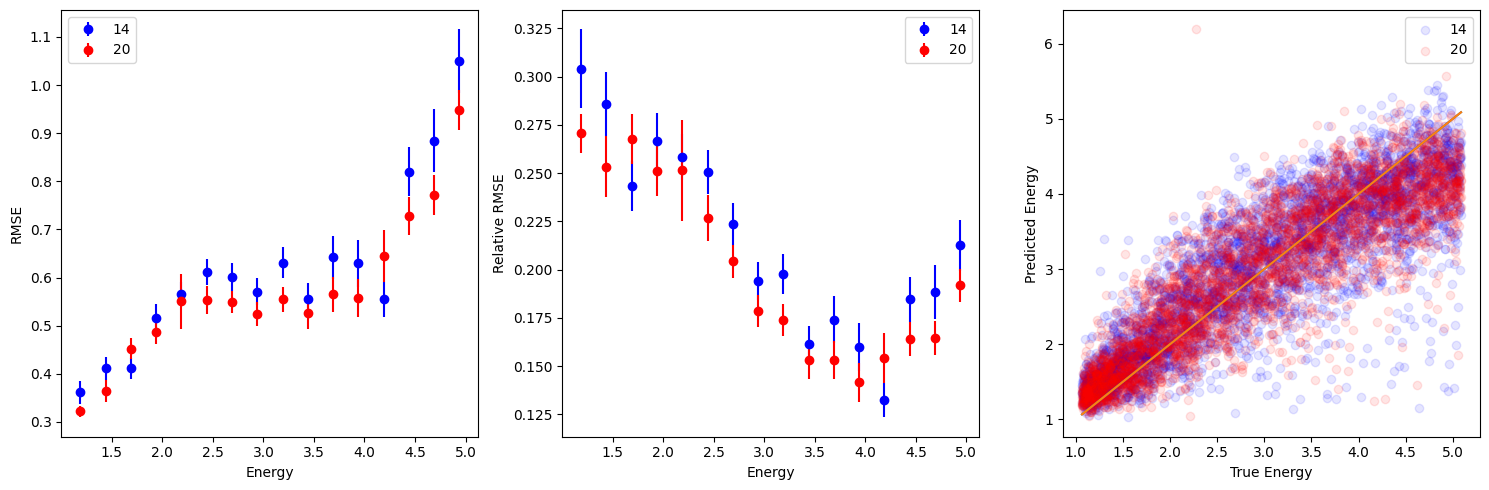

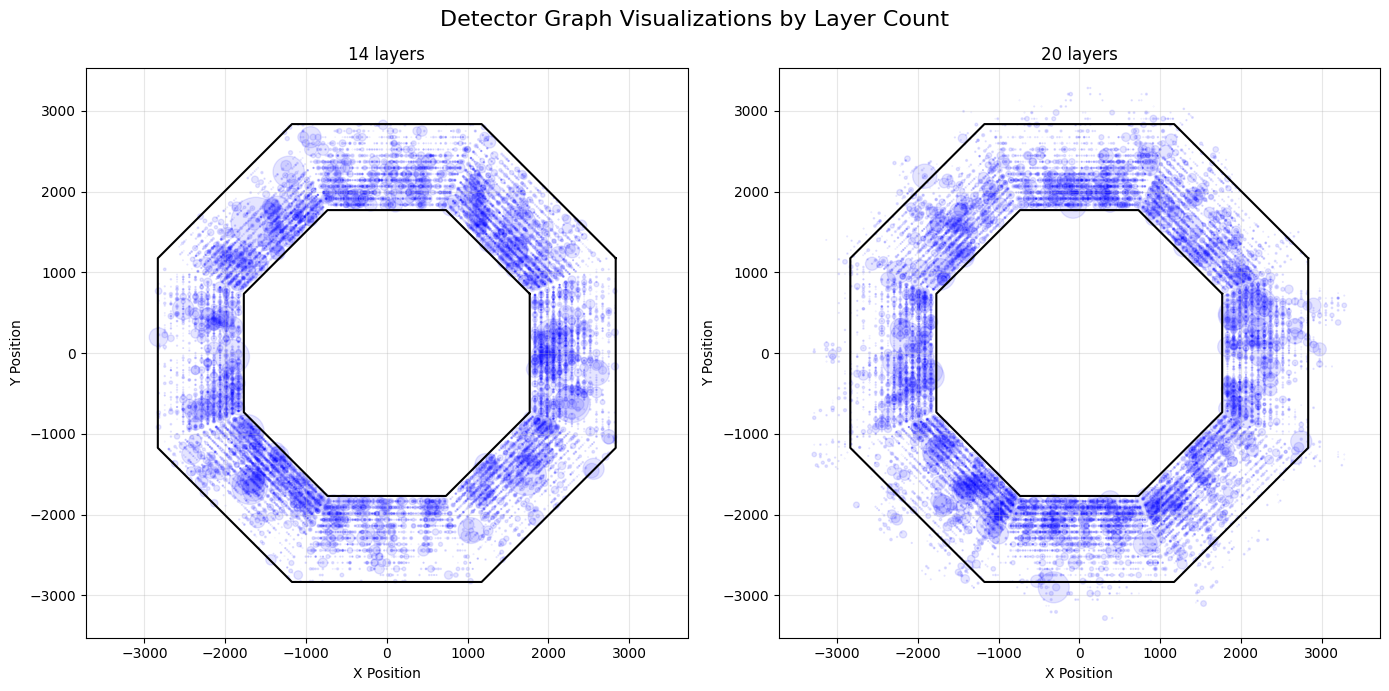

In [17]:

fig,axs = plot.subplots(1,3,figsize = (15,5))

# 2x2 figure for detector graph visualizations
viz_fig, viz_axs = plot.subplots(1, 2, figsize=(14, 7))
viz_axs_flat = viz_axs.flatten()

for i, val in enumerate(num_layers_vals):
    n_layers = run_num_to_layer[val]
    already_trained = n_layers in GNN_models and GNN_models[n_layers] is not None
    result = GNN_workflow(
        data_prefix = f"baseline_CFD_pixel_threshold_3_March_14_neutron_0_5GeV_to_5GeV500events_run_{val}_",
        run_num = val,
        viz_ax = viz_axs_flat[i],
        viz_title = f"{n_layers} layers",
        skip_training = already_trained
    )
    if result is not None:
        GNN_models[n_layers] = result
    curr_model = GNN_models[n_layers]
    rel_rmse_x,rel_rmse_y,scatter_x,scatter_y = get_text_positions(curr_model.bin_centers,curr_model.rel_rmse,curr_model.test_truths,curr_model.test_preds)
    def func(x, A):
        return A / np.sqrt(x)
    from scipy.optimize import curve_fit

    params, cov = curve_fit(func, curr_model.bin_centers, curr_model.rel_rmse, sigma = curr_model.rel_rmse_unc, absolute_sigma = True)
    x_fit = np.linspace(curr_model.bin_min.item(), curr_model.bin_max.item(), 100)
    y_fit = func(x_fit, params)
    y_fit_binned = func(curr_model.bin_centers, params)

    chi_squared = np.sum(((curr_model.rel_rmse - y_fit_binned) / curr_model.rel_rmse_unc)**2)
    reduced_chi_squared = chi_squared / (len(curr_model.bin_centers) - len(params))
    print(f"num_layers = {n_layers}:")
    print(f"\tReduced chi squared: {reduced_chi_squared}")

    axs[0].errorbar(curr_model.bin_centers,curr_model.rmse, yerr= curr_model.rmse_unc , fmt = 'o', label = f"{n_layers}",color = color_map[i])
    axs[0].set(xlabel="Energy",ylabel = "RMSE")
    axs[1].errorbar(curr_model.bin_centers,curr_model.rel_rmse, yerr = curr_model.rel_rmse_unc, fmt = 'o',label = f"{n_layers}",color = color_map[i])
#     axs[1].plot(x_fit,y_fit)
    axs[1].set(xlabel="Energy",ylabel = "Relative RMSE")
    print(f"\tA: {params[0]:.2f}")
    print(f"\tRMSE: {np.mean(curr_model.rmse):0.4f}")
    axs[2].scatter(curr_model.test_truths,curr_model.test_preds,alpha = 0.1,color = color_map[i], label = f"{n_layers}")
    axs[2].plot([min(curr_model.test_truths),max(curr_model.test_truths)],[min(curr_model.test_truths),max(curr_model.test_truths)])
    axs[2].set(xlabel = "True Energy",ylabel = "Predicted Energy")
    axs[0].legend()
    axs[1].legend()
    axs[2].legend()
    
fig.tight_layout()
viz_fig.suptitle("Detector Graph Visualizations by Layer Count", fontsize=16)
viz_fig.tight_layout()

In [20]:
fig.savefig("plots/GNN_results/ForPaper/RMSE_14_vs_20.pdf")
viz_fig.savefig("plots/GNN_results/ForPaper/Detector_vis_14_vs_20.pdf")

# **OLD PLOTS**

# Punch-Through Evidence Plots
Prove that the RMSE spike at high energies is caused by particles escaping the back of the calorimeter (punch-through). We use the **maximum hit layer index** per event as a proxy for shower penetration depth — events where the shower reaches the outermost layers (layer 13) are punch-through candidates.

In [91]:
# Extract max layer index, true energy, and predicted energy for test events
test_indices = list(range(num_val + num_train, num_examples))

test_max_layer = []
test_true_energies = []
test_pred_energies = []

trained_model.eval()
with torch.no_grad():
    for idx in test_indices:
        graph, labels_w_event_feats = dataset[idx]
        label = labels_w_event_feats[0].item()
        event_feats = labels_w_event_feats[1:].unsqueeze(0)
        pred = trained_model(graph, graph.ndata["feat"].float(), event_feats).detach().numpy()[0, 0]
        
        # Get max layer from the per-event dataframe stored during dataset construction
        event_df = dataset.dfs[idx]
        max_layer = event_df["layer_idx"].max()
        
        test_max_layer.append(max_layer)
        test_true_energies.append(label)
        test_pred_energies.append(pred)

test_max_layer = np.array(test_max_layer)
test_true_energies = np.array(test_true_energies)
test_pred_energies = np.array(test_pred_energies)
test_energy_error = test_pred_energies - test_true_energies

print(f"Test events: {len(test_max_layer)}")
print(f"Max layer range: {test_max_layer.min()} - {test_max_layer.max()}")
print(f"Fraction reaching outermost layer (13): {(test_max_layer == 13).sum() / len(test_max_layer):.3f}")

Test events: 3406
Max layer range: 0 - 13
Fraction reaching outermost layer (13): 0.135


## Plot 1: "Smoking Gun" — Energy Error vs Max Hit Layer
For high-energy particles (> 4 GeV), if punch-through is real, particles whose showers reach the outermost layers will be systematically **under-predicted** (negative energy error).

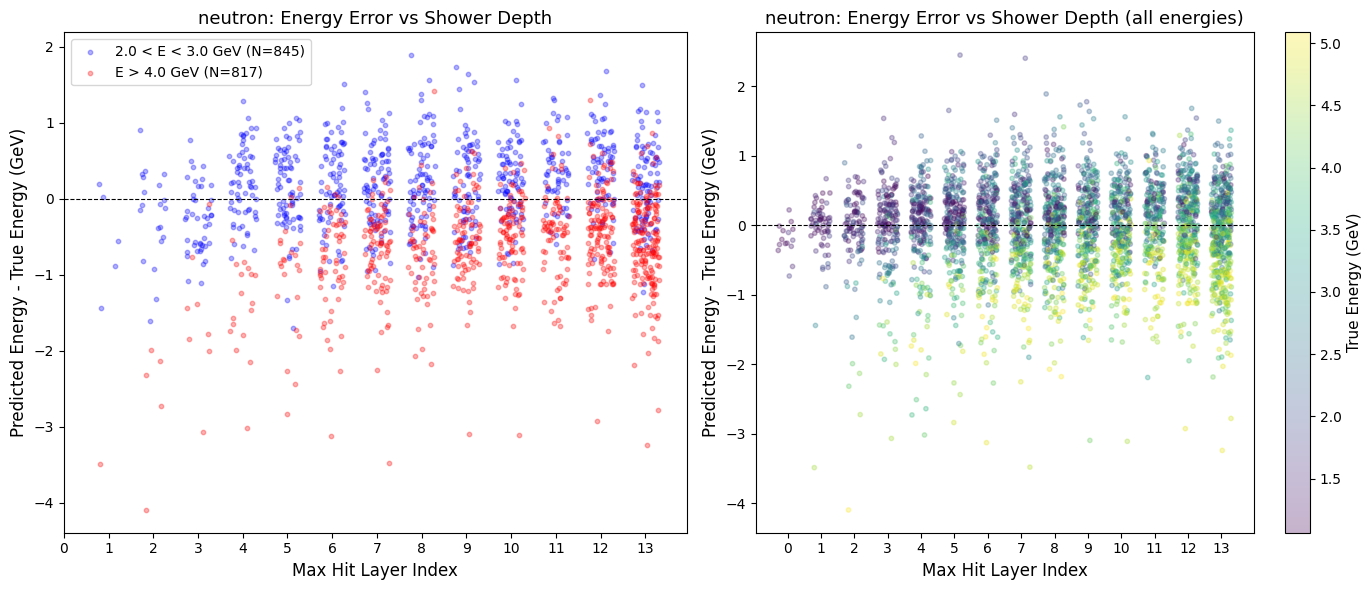

In [92]:
# Smoking Gun: Energy Error vs Max Hit Layer
fig_pt, axs_pt = plot.subplots(1, 2, figsize=(14, 6))

# Left: compare high-energy vs mid-energy events
high_e_mask = test_true_energies > 4.0
mid_e_mask = (test_true_energies > 2.0) & (test_true_energies <= 3.0)

# Add jitter to layer index for visibility in scatter
jitter = np.random.uniform(-0.3, 0.3, size=len(test_max_layer))

axs_pt[0].scatter(test_max_layer[mid_e_mask] + jitter[mid_e_mask], test_energy_error[mid_e_mask],
                  alpha=0.3, s=10, color='blue', label=f'2.0 < E < 3.0 GeV (N={mid_e_mask.sum()})')
axs_pt[0].scatter(test_max_layer[high_e_mask] + jitter[high_e_mask], test_energy_error[high_e_mask],
                  alpha=0.3, s=10, color='red', label=f'E > 4.0 GeV (N={high_e_mask.sum()})')
axs_pt[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8)
axs_pt[0].set_xlabel("Max Hit Layer Index", fontsize=12)
axs_pt[0].set_ylabel("Predicted Energy - True Energy (GeV)", fontsize=12)
axs_pt[0].set_title(f"{particle}: Energy Error vs Shower Depth", fontsize=13)
axs_pt[0].set_xticks(range(0, 14))
axs_pt[0].legend(fontsize=10)

# Right: color scatter by true energy for all events
sc = axs_pt[1].scatter(test_max_layer + jitter, test_energy_error,
                       c=test_true_energies, cmap='viridis', alpha=0.3, s=10)
axs_pt[1].axhline(y=0, color='k', linestyle='--', linewidth=0.8)
axs_pt[1].set_xlabel("Max Hit Layer Index", fontsize=12)
axs_pt[1].set_ylabel("Predicted Energy - True Energy (GeV)", fontsize=12)
axs_pt[1].set_title(f"{particle}: Energy Error vs Shower Depth (all energies)", fontsize=13)
axs_pt[1].set_xticks(range(0, 14))
cbar = plot.colorbar(sc, ax=axs_pt[1])
cbar.set_label("True Energy (GeV)", fontsize=11)

fig_pt.tight_layout()
# fig_pt.savefig(f"plots/GNN_results/{particle}_punchthrough_layer_scatter.pdf")

## Plot 2: Max Layer Histograms — Good vs Bad Predictions
For high-energy events (E > 4 GeV), split into "good" and "bad" predictions. If punch-through causes the degraded performance, "bad" predictions should be concentrated at the outermost layers.

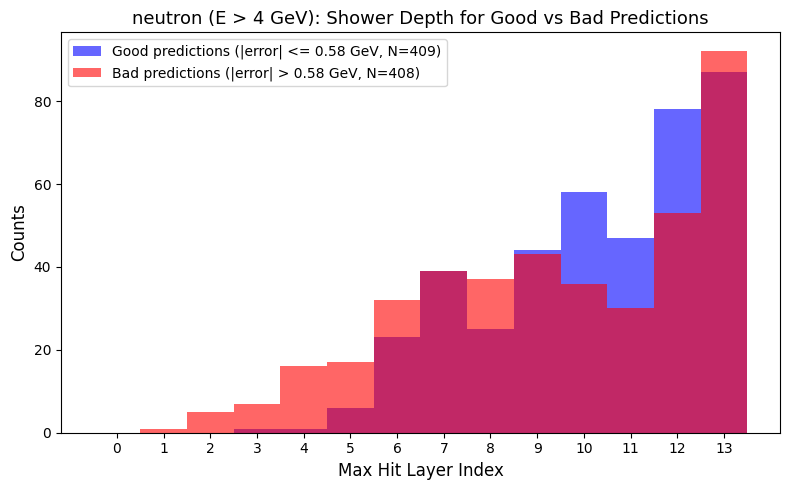

In [93]:
# Histogram comparison: max layer for good vs bad predictions at high energy
high_e_errors = test_energy_error[high_e_mask]
high_e_layers = test_max_layer[high_e_mask]

# Split by prediction quality using median absolute error as threshold
abs_errors = np.abs(high_e_errors)
error_threshold = np.median(abs_errors)

good_mask = abs_errors <= error_threshold
bad_mask = abs_errors > error_threshold

fig_hist, ax_hist = plot.subplots(figsize=(8, 5))
bins = np.arange(-0.5, 14.5, 1)  # integer bins for layer index

ax_hist.hist(high_e_layers[good_mask], bins=bins, alpha=0.6, color='blue',
             label=f'Good predictions (|error| <= {error_threshold:.2f} GeV, N={good_mask.sum()})')
ax_hist.hist(high_e_layers[bad_mask], bins=bins, alpha=0.6, color='red',
             label=f'Bad predictions (|error| > {error_threshold:.2f} GeV, N={bad_mask.sum()})')
ax_hist.set_xlabel("Max Hit Layer Index", fontsize=12)
ax_hist.set_ylabel("Counts", fontsize=12)
ax_hist.set_title(f"{particle} (E > 4 GeV): Shower Depth for Good vs Bad Predictions", fontsize=13)
ax_hist.set_xticks(range(0, 14))
ax_hist.legend(fontsize=10)

fig_hist.tight_layout()
# fig_hist.savefig(f"plots/GNN_results/{particle}_punchthrough_layer_histogram.pdf")

## Approach 1: Charge Fraction in Outermost Layers
Compute the fraction of total charge deposited in the last 2 layers (12-13) for each event. If punch-through is the cause of bad predictions, events with a high back-layer charge fraction should have larger (negative) energy errors — the shower is still developing when it runs out of detector.

In [94]:
# Compute back-layer charge fraction for each test event
test_back_frac = []

for idx in test_indices:
    event_df = dataset.dfs[idx]
    total_charge = event_df["Charge0"].sum() + event_df["Charge1"].sum()
    back_hits = event_df[event_df["layer_idx"] >= 12]
    back_charge = back_hits["Charge0"].sum() + back_hits["Charge1"].sum()
    test_back_frac.append(back_charge / total_charge if total_charge > 0 else 0.0)

test_back_frac = np.array(test_back_frac)

print(f"Back-layer charge fraction range: {test_back_frac.min():.3f} - {test_back_frac.max():.3f}")
print(f"Mean: {test_back_frac.mean():.3f}, Median: {np.median(test_back_frac):.3f}")

Back-layer charge fraction range: 0.000 - 1.000
Mean: 0.021, Median: 0.000


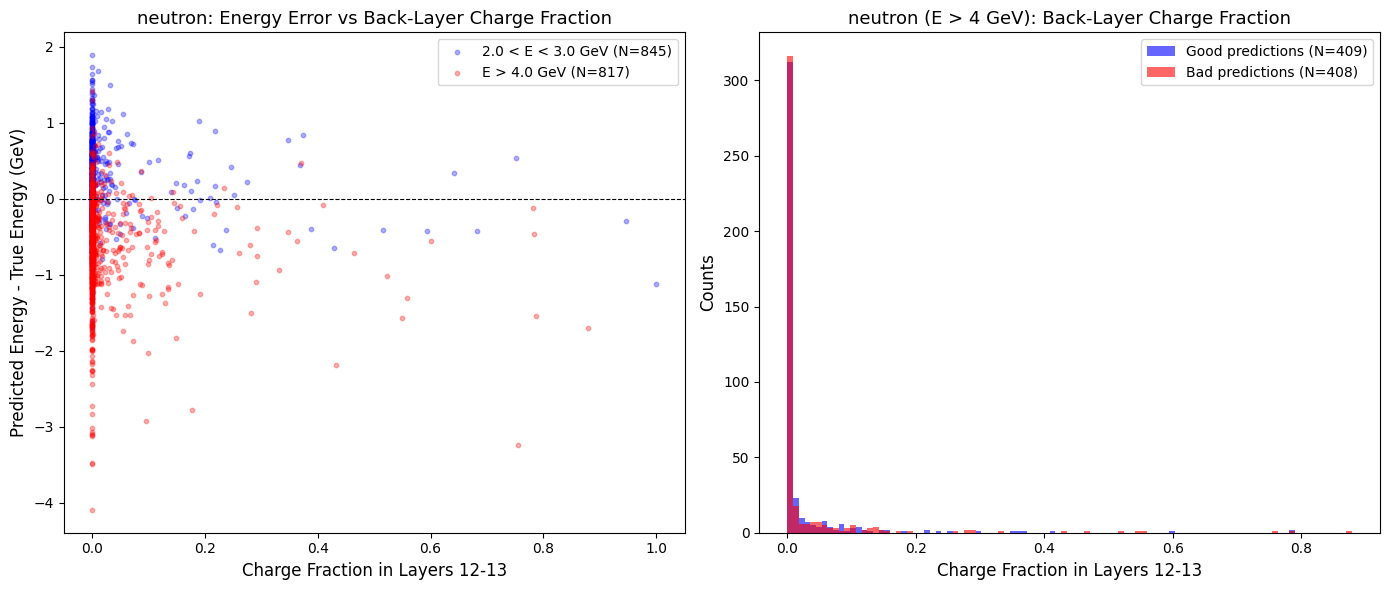

In [99]:
# Approach 1 plots: Energy error vs back-layer charge fraction
fig_frac, axs_frac = plot.subplots(1, 2, figsize=(14, 6))

# Left: scatter for high-energy vs mid-energy
axs_frac[0].scatter(test_back_frac[mid_e_mask], test_energy_error[mid_e_mask],
                    alpha=0.3, s=10, color='blue', label=f'2.0 < E < 3.0 GeV (N={mid_e_mask.sum()})')
axs_frac[0].scatter(test_back_frac[high_e_mask], test_energy_error[high_e_mask],
                    alpha=0.3, s=10, color='red', label=f'E > 4.0 GeV (N={high_e_mask.sum()})')
axs_frac[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8)
axs_frac[0].set_xlabel("Charge Fraction in Layers 12-13", fontsize=12)
axs_frac[0].set_ylabel("Predicted Energy - True Energy (GeV)", fontsize=12)
axs_frac[0].set_title(f"{particle}: Energy Error vs Back-Layer Charge Fraction", fontsize=13)
axs_frac[0].legend(fontsize=10)

# Right: histogram of back-layer charge fraction for good vs bad predictions (high E only)
high_e_back_frac = test_back_frac[high_e_mask]
high_e_abs_err = np.abs(test_energy_error[high_e_mask])
frac_err_threshold = np.median(high_e_abs_err)
good = high_e_abs_err <= frac_err_threshold
bad = high_e_abs_err > frac_err_threshold

bins_frac = np.linspace(0, high_e_back_frac.max(), 100)
axs_frac[1].hist(high_e_back_frac[good], bins=bins_frac, alpha=0.6, color='blue',
                 label=f'Good predictions (N={good.sum()})')
axs_frac[1].hist(high_e_back_frac[bad], bins=bins_frac, alpha=0.6, color='red',
                 label=f'Bad predictions (N={bad.sum()})')
axs_frac[1].set_xlabel("Charge Fraction in Layers 12-13", fontsize=12)
axs_frac[1].set_ylabel("Counts", fontsize=12)
axs_frac[1].set_title(f"{particle} (E > 4 GeV): Back-Layer Charge Fraction", fontsize=13)
axs_frac[1].legend(fontsize=10)

fig_frac.tight_layout()
fig_frac.savefig(f"plots/GNN_results/{particle}_punchthrough_charge_fraction.pdf")

## Approach 2: Total Charge vs True Energy
If containment is the issue, the relationship between total detected charge and true energy should flatten or saturate at high energies — a "missing charge" signature where some energy escapes undetected.

In [97]:
# Compute total charge for each test event
test_total_charge = []

for idx in test_indices:
    event_df = dataset.dfs[idx]
    total_charge = event_df["Charge0"].sum() + event_df["Charge1"].sum()
    test_total_charge.append(total_charge)

test_total_charge = np.array(test_total_charge)

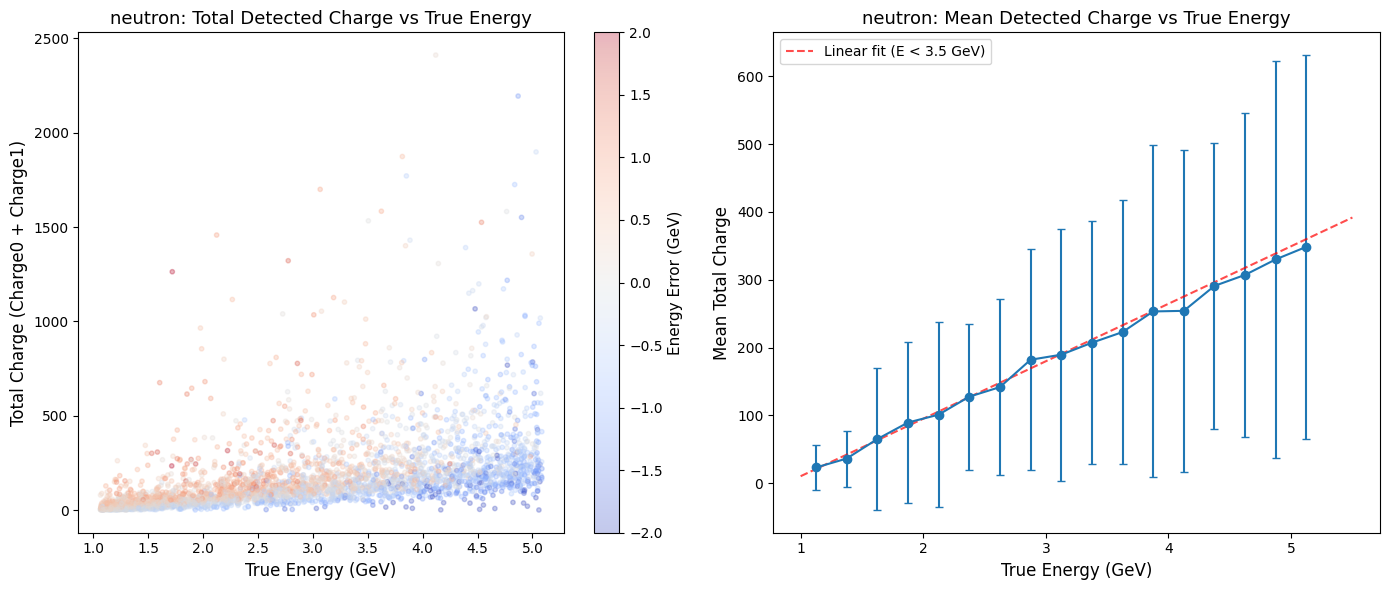

In [100]:
# Approach 2 plots: Total charge vs true energy
fig_charge, axs_charge = plot.subplots(1, 2, figsize=(14, 6))

# Left: total charge vs true energy, colored by energy error
sc2 = axs_charge[0].scatter(test_true_energies, test_total_charge,
                            c=test_energy_error, cmap='coolwarm', alpha=0.3, s=10,
                            vmin=-2, vmax=2)
axs_charge[0].set_xlabel("True Energy (GeV)", fontsize=12)
axs_charge[0].set_ylabel("Total Charge (Charge0 + Charge1)", fontsize=12)
axs_charge[0].set_title(f"{particle}: Total Detected Charge vs True Energy", fontsize=13)
cbar2 = plot.colorbar(sc2, ax=axs_charge[0])
cbar2.set_label("Energy Error (GeV)", fontsize=11)

# Right: binned mean and std of total charge vs true energy
# Shows whether the charge-energy relationship saturates
energy_bins = np.arange(1.0, 5.5, 0.25)
bin_centers_charge = (energy_bins[:-1] + energy_bins[1:]) / 2
mean_charge = []
std_charge = []
for i in range(len(energy_bins) - 1):
    mask = (test_true_energies >= energy_bins[i]) & (test_true_energies < energy_bins[i+1])
    if mask.sum() > 0:
        mean_charge.append(test_total_charge[mask].mean())
        std_charge.append(test_total_charge[mask].std())
    else:
        mean_charge.append(np.nan)
        std_charge.append(np.nan)

mean_charge = np.array(mean_charge)
std_charge = np.array(std_charge)

axs_charge[1].errorbar(bin_centers_charge, mean_charge, yerr=std_charge, fmt='o-', capsize=3)
axs_charge[1].set_xlabel("True Energy (GeV)", fontsize=12)
axs_charge[1].set_ylabel("Mean Total Charge", fontsize=12)
axs_charge[1].set_title(f"{particle}: Mean Detected Charge vs True Energy", fontsize=13)

# Add a linear fit to the low-energy region to show deviation
low_e_fit_mask = bin_centers_charge < 3.5
valid = ~np.isnan(mean_charge) & low_e_fit_mask
if valid.sum() > 1:
    coeffs = np.polyfit(bin_centers_charge[valid], mean_charge[valid], 1)
    x_line = np.linspace(1.0, 5.5, 100)
    axs_charge[1].plot(x_line, np.polyval(coeffs, x_line), 'r--', 
                       label=f'Linear fit (E < 3.5 GeV)', alpha=0.7)
    axs_charge[1].legend(fontsize=10)

fig_charge.tight_layout()
fig_charge.savefig(f"plots/GNN_results/{particle}_total_charge_vs_energy.pdf")

# Conventional Baseline: Energy from Charge
Compare the GNN performance against conventional (non-ML) energy estimation methods:
1. **Total charge**: Simple linear calibration E = a * Q_total + b
2. **Per-layer charge**: Linear regression on the charge deposited in each layer (14 features)

Both are trained on the same train split and evaluated on the same test split for a fair comparison.

In [101]:
from sklearn.linear_model import LinearRegression

n_layers = 14  # layers 0-13

# Build feature arrays for all events in the dataset
all_layer_charges = []  # per-layer charge (n_layers features)
all_total_charges = []  # total charge (1 feature)
all_energies = []       # true energy (label)

for idx in range(len(dataset)):
    event_df = dataset.dfs[idx]
    label = dataset.labels[idx, 0].item()
    
    # Sum Charge0 + Charge1 per layer
    layer_charge = np.zeros(n_layers)
    for _, row in event_df.iterrows():
        l = int(row["layer_idx"])
        if 0 <= l < n_layers:
            layer_charge[l] += row["Charge0"] + row["Charge1"]
    
    all_layer_charges.append(layer_charge)
    all_total_charges.append(layer_charge.sum())
    all_energies.append(label)

all_layer_charges = np.array(all_layer_charges)
all_total_charges = np.array(all_total_charges).reshape(-1, 1)
all_energies = np.array(all_energies)

# Use same train/test split indices as the GNN
train_idx = list(range(num_train))
test_idx = list(range(num_val + num_train, num_examples))

# Method 1: Total charge linear calibration
reg_total = LinearRegression()
reg_total.fit(all_total_charges[train_idx], all_energies[train_idx])
pred_total = reg_total.predict(all_total_charges[test_idx])

# Method 2: Per-layer charge linear regression
reg_layer = LinearRegression()
reg_layer.fit(all_layer_charges[train_idx], all_energies[train_idx])
pred_layer = reg_layer.predict(all_layer_charges[test_idx])

true_test = all_energies[test_idx]

print(f"Total charge calibration: E = {reg_total.coef_[0]:.4f} * Q + {reg_total.intercept_:.4f}")
print(f"Per-layer regression R^2 (train): {reg_layer.score(all_layer_charges[train_idx], all_energies[train_idx]):.4f}")
print(f"Per-layer coefficients by layer: {np.array2string(reg_layer.coef_, precision=4)}")

Total charge calibration: E = 0.0033 * Q + 2.3965
Per-layer regression R^2 (train): 0.2800
Per-layer coefficients by layer: [0.0045 0.0038 0.0032 0.0025 0.0028 0.0036 0.004  0.0027 0.0029 0.0054
 0.0029 0.0016 0.0051 0.0042]


In [102]:
# Compute binned RMSE for both conventional methods and GNN
def compute_binned_rmse(true, pred, bin_width=0.25, bin_min=None, bin_max=None):
    if bin_min is None:
        bin_min = true.min()
    if bin_max is None:
        bin_max = true.max()
    edges = np.arange(bin_min, bin_max + bin_width, bin_width)
    centers = (edges[:-1] + edges[1:]) / 2
    rmse_vals = []
    for i in range(len(edges) - 1):
        mask = (true >= edges[i]) & (true < edges[i+1])
        if mask.sum() > 1:
            rmse_vals.append(np.sqrt(np.mean((pred[mask] - true[mask])**2)))
        else:
            rmse_vals.append(np.nan)
    return centers, np.array(rmse_vals)

# Use the same bin range as the GNN plots
bmin = bin_min.item() if hasattr(bin_min, 'item') else float(bin_min)
bmax = bin_max.item() if hasattr(bin_max, 'item') else float(bin_max)

c_total, rmse_total = compute_binned_rmse(true_test, pred_total, bin_width=0.25, bin_min=bmin, bin_max=bmax)
c_layer, rmse_layer = compute_binned_rmse(true_test, pred_layer, bin_width=0.25, bin_min=bmin, bin_max=bmax)

# GNN test predictions (reuse test_true_energies and test_pred_energies from earlier)
c_gnn, rmse_gnn = compute_binned_rmse(test_true_energies, test_pred_energies, bin_width=0.25, bin_min=bmin, bin_max=bmax)

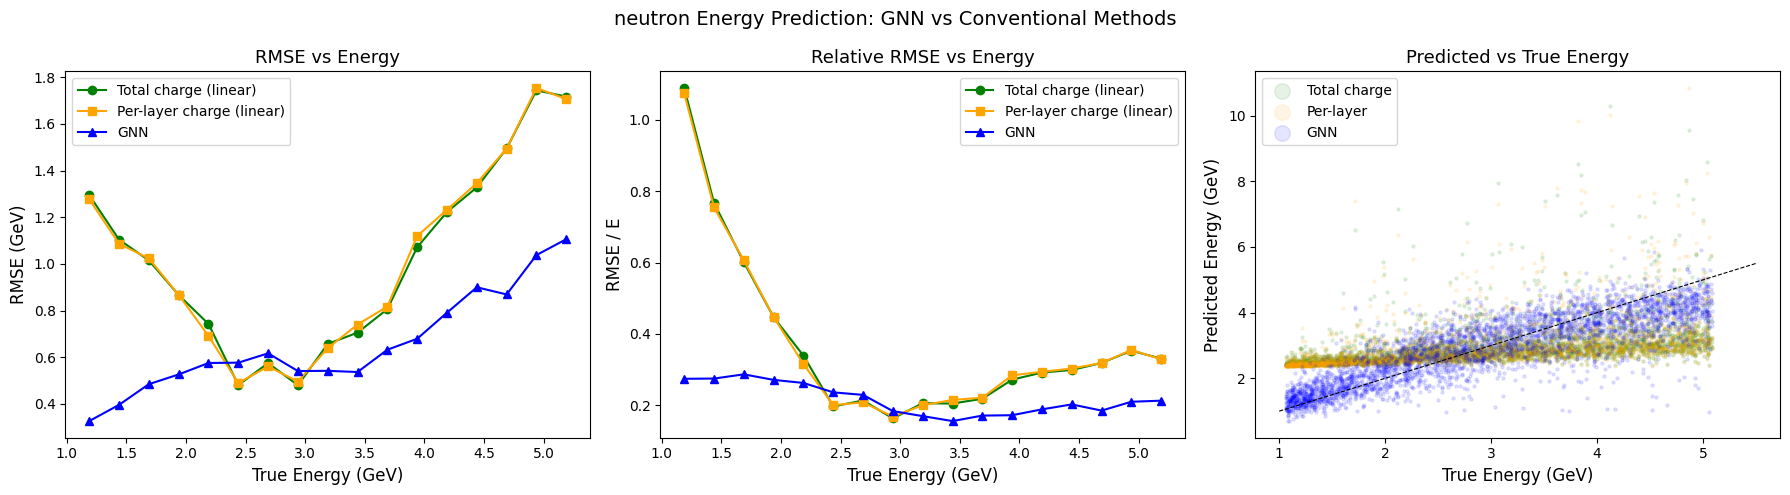

In [104]:
# Comparison plots: RMSE vs E and RMSE/E vs E for all three methods
fig_comp, axs_comp = plot.subplots(1, 3, figsize=(18, 5))
fig_comp.suptitle(f"{particle} Energy Prediction: GNN vs Conventional Methods", fontsize=14)

# Left: RMSE vs E
axs_comp[0].plot(c_total, rmse_total, 'o-', label='Total charge (linear)', color='green')
axs_comp[0].plot(c_layer, rmse_layer, 's-', label='Per-layer charge (linear)', color='orange')
axs_comp[0].plot(c_gnn, rmse_gnn, '^-', label='GNN', color='blue')
axs_comp[0].set_xlabel("True Energy (GeV)", fontsize=12)
axs_comp[0].set_ylabel("RMSE (GeV)", fontsize=12)
axs_comp[0].set_title("RMSE vs Energy", fontsize=13)
axs_comp[0].legend(fontsize=10)

# Middle: RMSE/E vs E
axs_comp[1].plot(c_total, rmse_total / c_total, 'o-', label='Total charge (linear)', color='green')
axs_comp[1].plot(c_layer, rmse_layer / c_layer, 's-', label='Per-layer charge (linear)', color='orange')
axs_comp[1].plot(c_gnn, rmse_gnn / c_gnn, '^-', label='GNN', color='blue')
axs_comp[1].set_xlabel("True Energy (GeV)", fontsize=12)
axs_comp[1].set_ylabel("RMSE / E", fontsize=12)
axs_comp[1].set_title("Relative RMSE vs Energy", fontsize=13)
axs_comp[1].legend(fontsize=10)

# Right: Pred vs True scatter for all three
axs_comp[2].scatter(true_test, pred_total, alpha=0.1, s=5, color='green', label='Total charge')
axs_comp[2].scatter(true_test, pred_layer, alpha=0.1, s=5, color='orange', label='Per-layer')
axs_comp[2].scatter(test_true_energies, test_pred_energies, alpha=0.1, s=5, color='blue', label='GNN')
axs_comp[2].plot([1, 5.5], [1, 5.5], 'k--', linewidth=0.8)
axs_comp[2].set_xlabel("True Energy (GeV)", fontsize=12)
axs_comp[2].set_ylabel("Predicted Energy (GeV)", fontsize=12)
axs_comp[2].set_title("Predicted vs True Energy", fontsize=13)
axs_comp[2].legend(fontsize=10, markerscale=5)

fig_comp.tight_layout()
fig_comp.savefig(f"plots/GNN_results/{particle}_GNN_vs_conventional.pdf")

In [89]:
GNN_num = 3

In [90]:

rel_rmse_times_sqrtE = rmse /  np.sqrt(bin_centers)
axs2[0].scatter(rmse_per_bin.keys(),rmse_per_bin.values(), label = f"GNN #{GNN_num}")
axs2[0].set(xlabel="Energy",ylabel = "RMSE")
axs2[1].scatter(rmse_per_bin.keys(),np.array(list(rmse_per_bin.values())) / np.array(list(rmse_per_bin.keys())), label = f"GNN #{GNN_num}")
axs2[1].plot(x_fit,y_fit)
axs2[1].set(xlabel="Energy",ylabel = "Relative RMSE")
axs2[1].text(rel_rmse_x,rel_rmse_y,f"A: {params[0]:.2f}")
text_spacing = (max(rmse_per_bin.values()) - min(rmse_per_bin.values())) / 20
axs2[1].text(rel_rmse_x,rel_rmse_y + text_spacing,f"f(x) = A/sqrt(E)")
axs2[2].scatter(rmse_per_bin.keys(),rel_rmse_times_sqrtE, label = f"GNN #{GNN_num}")
axs2[2].set(xlabel="Energy",ylabel = "RMSE/sqrt(E)")
axs2[3].scatter(test_truths,test_preds,alpha = 0.1,color = "r", label = f"GNN #{GNN_num}")
axs2[3].text(scatter_x,scatter_y,f"Test Root Mean Squared Error:\n{np.mean(list(rmse_per_bin.values())):0.4f}")
axs2[3].plot([min(test_truths),max(test_truths)],[min(test_truths),max(test_truths)])
axs2[3].set(xlabel = "True Energy",ylabel = "Predicted Energy")

[Text(0.5, 4.444444444444445, 'True Energy'),
 Text(1217.487922705314, 0.5, 'Predicted Energy')]

In [91]:
axs2[0].legend()
axs2[1].legend()
axs2[2].legend()
axs2[3].legend()
fig2.savefig(f"plots/test/neutron_run_1_3_plots_together.pdf")

#### Only run this once after running all gnn runs

## Trying to instead plot Relative RMSE * sqrt(E) vs E

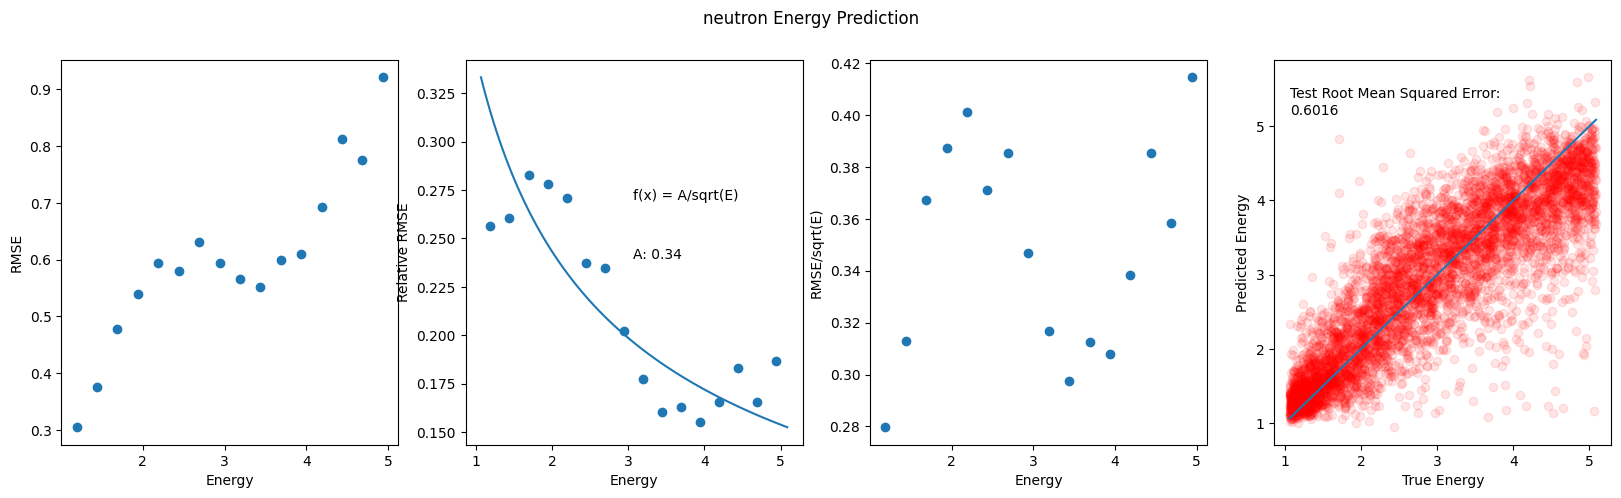

In [27]:
rel_rmse_times_sqrtE = rmse /  np.sqrt(bin_centers)

fig2,axs2 = plot.subplots(1,4,figsize = (20,5))
fig2.suptitle(f"{particle} Energy Prediction")
axs2[0].scatter(rmse_per_bin.keys(),rmse_per_bin.values())
axs2[0].set(xlabel="Energy",ylabel = "RMSE")
axs2[1].scatter(rmse_per_bin.keys(),np.array(list(rmse_per_bin.values())) / np.array(list(rmse_per_bin.keys())))
axs2[1].plot(x_fit,y_fit)
axs2[1].set(xlabel="Energy",ylabel = "Relative RMSE")
axs2[1].text(rel_rmse_x,rel_rmse_y,f"A: {params[0]:.2f}")
text_spacing = (max(rmse_per_bin.values()) - min(rmse_per_bin.values())) / 20
axs2[1].text(rel_rmse_x,rel_rmse_y + text_spacing,f"f(x) = A/sqrt(E)")
axs2[2].scatter(rmse_per_bin.keys(),rel_rmse_times_sqrtE)
axs2[2].set(xlabel="Energy",ylabel = "RMSE/sqrt(E)")
axs2[3].scatter(test_truths,test_preds,alpha = 0.1,color = "r")
axs2[3].text(scatter_x,scatter_y,f"Test Root Mean Squared Error:\n{np.mean(list(rmse_per_bin.values())):0.4f}")
axs2[3].plot([min(test_truths),max(test_truths)],[min(test_truths),max(test_truths)])
axs2[3].set(xlabel = "True Energy",ylabel = "Predicted Energy")
fig.tight_layout()
# plot.savefig(f"plots/test/neutron_run_1_training_4.pdf")
# plot.savefig(f"plots/GNN_results/Dec_4_{particle}_ENERGY_1GeV_to_5GeV50events_3pixel_threshold_CFD.pdf")
# plot.savefig(f"plots/GNN/March_20_K_L_run_{run_num}_RMSE_k_6.pdf")

In [29]:
neutron_RMSE_over_sqrt_E = np.array([0.73579088, 0.63357413, 0.61852611, 0.58341604, 0.5282935,  0.52071224,
 0.47786107, 0.43421205, 0.41919379, 0.3875516,  0.34955458, 0.33502813,
 0.32392302, 0.32688518, 0.37688865, 0.40574931, 0.47153768, 0.49782188])
neutron_bin_centers = np.array([1.18936431, 1.43936431, 1.68936431, 1.93936431, 2.18936431, 2.43936431,
 2.68936431, 2.93936431, 3.18936431, 3.43936431, 3.68936431, 3.93936431,
 4.18936431, 4.43936431, 4.68936431, 4.93936431])
neutron_RMSE = np.array([0.29331544, 0.40065169, 0.46128437, 0.54788077, 0.54145008, 0.62603289,
 0.56570745, 0.59227055, 0.59815365, 0.57337487, 0.6025573,  0.60855889,
 0.55957776, 0.6323806,  0.7826913,  0.84499782])

In [30]:
kaon0L_RMSE_over_sqrt_E = np.array([0.54869331, 0.51203519, 0.55476497, 0.4795935,  0.51562511, 0.48449919,
 0.45721273, 0.44132724, 0.42930314, 0.39032752, 0.38599007, 0.34805265,
 0.34791832, 0.35907611, 0.39836053, 0.46906796, 0.49353348])
kaon0L_bin_centers = np.array([0.83046448, 1.08046448, 1.33046448, 1.58046448, 1.83046448, 2.08046448,
 2.33046448, 2.58046448, 2.83046448, 3.08046448, 3.33046448, 3.58046448,
 3.83046448, 4.08046448, 4.33046448, 4.58046448, 4.83046448])
kaon0L_RMSE = np.array([0.50002325, 0.53223699, 0.63989788, 0.60292828, 0.69761324, 0.69883269,
 0.6979745,  0.70894033, 0.72225893, 0.68507367, 0.7044149,  0.65858924,
 0.68093085, 0.72533947, 0.82897902, 1.00390017, 1.08470356])

In [31]:
pion_RMSE_over_sqrt_E = np.array([0.73579088, 0.63357413, 0.61852611, 0.58341604, 0.5282935,  0.52071224
, 0.47786107, 0.43421205, 0.41919379, 0.3875516,  0.34955458, 0.33502813
, 0.32392302, 0.32688518, 0.37688865, 0.40574931, 0.47153768, 0.49782188])
pion_bin_centers = np.array([0.64423102, 0.89423102, 1.14423102, 1.39423102, 1.64423102, 1.89423102
, 2.14423102, 2.39423102, 2.64423102, 2.89423102, 3.14423102, 3.39423102
, 3.64423102, 3.89423102, 4.14423102, 4.39423102, 4.64423102, 4.89423102])
pion_RMSE = np.array([0.59057522, 0.5991317,  0.66162956, 0.68888342, 0.67741793, 0.71666181
, 0.69974118, 0.67186946, 0.68165487, 0.65931982, 0.61982948, 0.61723703
, 0.61836481, 0.64506888, 0.76724672, 0.8505488,  1.01618624, 1.10132682]
)

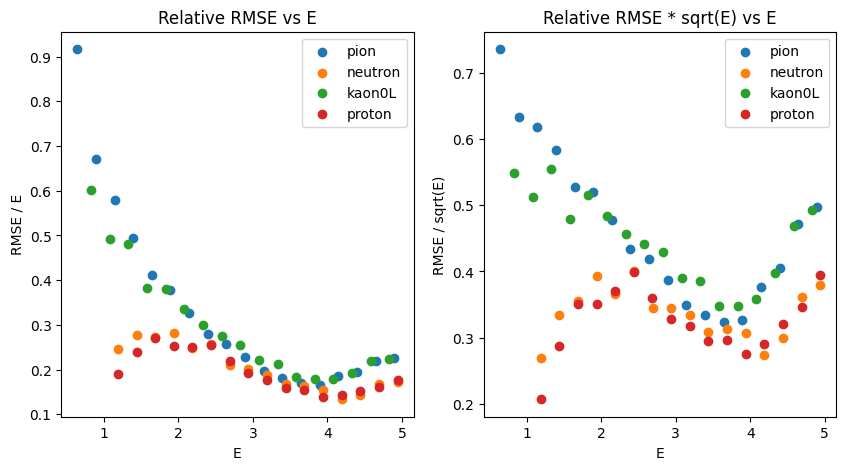

In [33]:
fig_both, axs_both = plot.subplots(1,2, figsize = (10,5))
axs_both[0].scatter(pion_bin_centers, pion_RMSE / pion_bin_centers, label = "pion")
axs_both[0].scatter(neutron_bin_centers, neutron_RMSE / neutron_bin_centers, label = "neutron")
axs_both[0].scatter(kaon0L_bin_centers, kaon0L_RMSE / kaon0L_bin_centers, label = "kaon0L")
axs_both[0].scatter(bin_centers, rmse / bin_centers, label = "proton")
axs_both[0].legend()
axs_both[0].set(title = "Relative RMSE vs E", ylabel = "RMSE / E", xlabel = "E")

axs_both[1].scatter(pion_bin_centers, pion_RMSE / np.sqrt(pion_bin_centers), label = "pion")
axs_both[1].scatter(neutron_bin_centers, neutron_RMSE / np.sqrt(neutron_bin_centers), label = "neutron")
axs_both[1].scatter(kaon0L_bin_centers, kaon0L_RMSE / np.sqrt(kaon0L_bin_centers), label = "kaon0L")
axs_both[1].scatter(bin_centers, rmse / np.sqrt(bin_centers), label = "proton")
axs_both[1].legend()
axs_both[1].set(title = "Relative RMSE * sqrt(E) vs E", ylabel = "RMSE / sqrt(E)", xlabel = "E")
fig_both.savefig("plots/GNN_results/pion_vs_neutron_vs_kaon0L_vs_proton_resolution.pdf")

In [127]:
print(neutron_RMSE_over_sqrt_E)

[0.73579088 0.63357413 0.61852611 0.58341604 0.5282935  0.52071224
 0.47786107 0.43421205 0.41919379 0.3875516  0.34955458 0.33502813
 0.32392302 0.32688518 0.37688865 0.40574931 0.47153768 0.49782188]


In [128]:
print(neutron_bin_centers)

[1.18936431 1.43936431 1.68936431 1.93936431 2.18936431 2.43936431
 2.68936431 2.93936431 3.18936431 3.43936431 3.68936431 3.93936431
 4.18936431 4.43936431 4.68936431 4.93936431]


In [129]:
print(neutron_RMSE)

[0.29331544 0.40065169 0.46128437 0.54788077 0.54145008 0.62603289
 0.56570745 0.59227055 0.59815365 0.57337487 0.6025573  0.60855889
 0.55957776 0.6323806  0.7826913  0.84499782]


In [133]:
print(pion_RMSE_over_sqrt_E)

[0.73579088 0.63357413 0.61852611 0.58341604 0.5282935  0.52071224
 0.47786107 0.43421205 0.41919379 0.3875516  0.34955458 0.33502813
 0.32392302 0.32688518 0.37688865 0.40574931 0.47153768 0.49782188]


In [134]:
print(pion_bin_centers)

[0.64423102 0.89423102 1.14423102 1.39423102 1.64423102 1.89423102
 2.14423102 2.39423102 2.64423102 2.89423102 3.14423102 3.39423102
 3.64423102 3.89423102 4.14423102 4.39423102 4.64423102 4.89423102]


In [135]:
print(pion_RMSE)

[0.59057522 0.5991317  0.66162956 0.68888342 0.67741793 0.71666181
 0.69974118 0.67186946 0.68165487 0.65931982 0.61982948 0.61723703
 0.61836481 0.64506888 0.76724672 0.8505488  1.01618624 1.10132682]


In [137]:
print(kaon0L_RMSE_over_sqrt_E)

[0.54869331 0.51203519 0.55476497 0.4795935  0.51562511 0.48449919
 0.45721273 0.44132724 0.42930314 0.39032752 0.38599007 0.34805265
 0.34791832 0.35907611 0.39836053 0.46906796 0.49353348]


In [138]:
print(kaon0L_bin_centers)

[0.83046448 1.08046448 1.33046448 1.58046448 1.83046448 2.08046448
 2.33046448 2.58046448 2.83046448 3.08046448 3.33046448 3.58046448
 3.83046448 4.08046448 4.33046448 4.58046448 4.83046448]


In [139]:
print(kaon0L_RMSE)

[0.50002325 0.53223699 0.63989788 0.60292828 0.69761324 0.69883269
 0.6979745  0.70894033 0.72225893 0.68507367 0.7044149  0.65858924
 0.68093085 0.72533947 0.82897902 1.00390017 1.08470356]
